<a href="https://colab.research.google.com/github/harpreetsingh171190-cmyk/-hvac-thermal-load-predictor/blob/main/HVAC_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

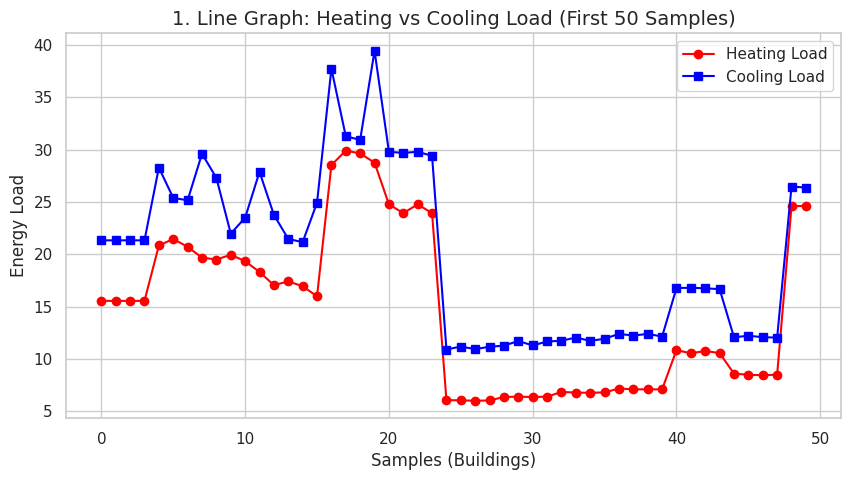

/tmp/ipykernel_3299/834971132.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Orientation', y='Heating_Load', data=df, errorbar=None, palette='viridis')


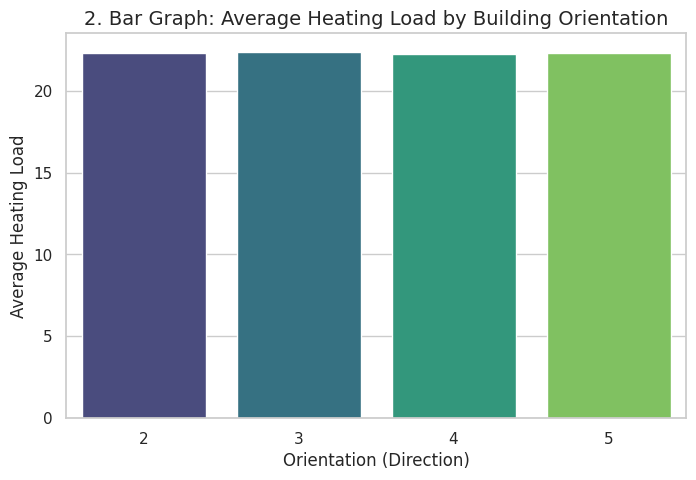

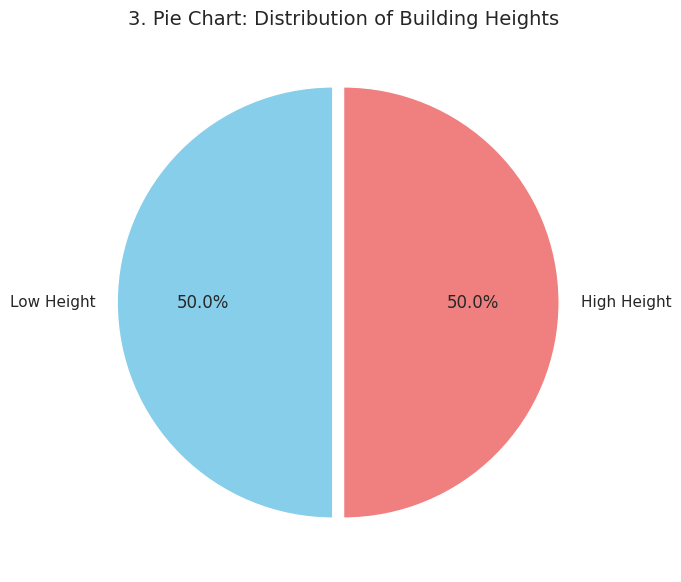

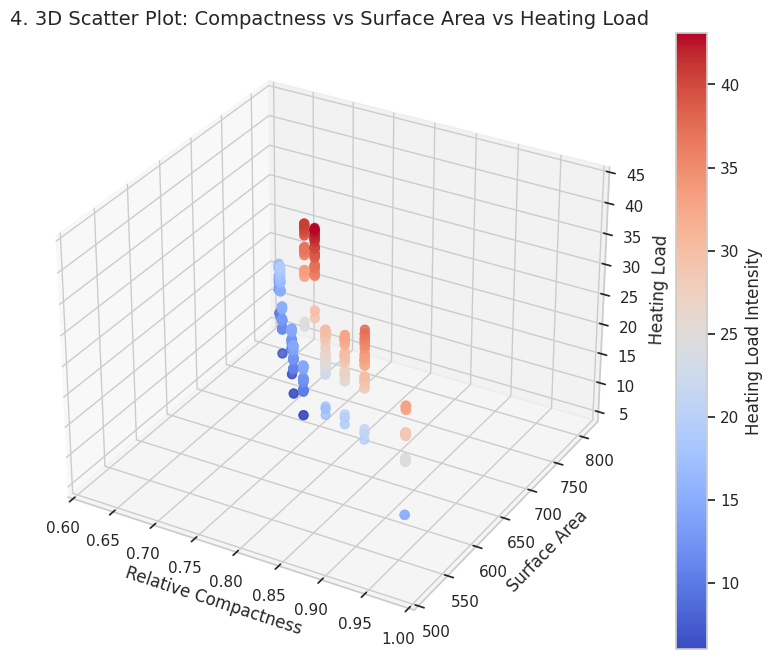

In [ ]:

# Import necessary libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# 1. Load the Dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)

# 2. Rename columns to English for clear understanding
df.columns = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
              'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution',
              'Heating_Load', 'Cooling_Load']

# Set the visual style for the graphs
sns.set_theme(style="whitegrid")

# ==========================================
# GRAPH 1: Line Graph (Heating vs Cooling Load)
# ==========================================
plt.figure(figsize=(10, 5))
# Taking first 50 samples so the graph looks clear and easy to read
plt.plot(df['Heating_Load'][:50], label='Heating Load', marker='o', color='red')
plt.plot(df['Cooling_Load'][:50], label='Cooling Load', marker='s', color='blue')
plt.title('1. Line Graph: Heating vs Cooling Load (First 50 Samples)', fontsize=14)
plt.xlabel('Samples (Buildings)')
plt.ylabel('Energy Load')
plt.legend()
plt.show()

# ==========================================
# GRAPH 2: Bar Graph (Average Heating Load by Orientation)
# ==========================================
plt.figure(figsize=(8, 5))
sns.barplot(x='Orientation', y='Heating_Load', data=df, errorbar=None, palette='viridis')
plt.title('2. Bar Graph: Average Heating Load by Building Orientation', fontsize=14)
plt.xlabel('Orientation (Direction)')
plt.ylabel('Average Heating Load')
plt.show()

# ==========================================
# GRAPH 3: Pie Chart (Distribution of Building Heights)
# ==========================================
plt.figure(figsize=(7, 7))
# Counting how many buildings have which height
height_counts = df['Overall_Height'].value_counts()
plt.pie(height_counts, labels=['Low Height', 'High Height'], autopct='%1.1f%%',
        colors=['skyblue', 'lightcoral'], startangle=90, explode=(0.05, 0))
plt.title('3. Pie Chart: Distribution of Building Heights', fontsize=14)
plt.show()

# ==========================================
# GRAPH 4: 3D Scatter Plot (Compactness vs Surface Area vs Heating Load)
# ==========================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotting the 3D graph
x = df['Relative_Compactness']
y = df['Surface_Area']
z = df['Heating_Load']

# Color mapping based on Heating Load (Z-axis)
scatter = ax.scatter(x, y, z, c=z, cmap='coolwarm', s=40)

ax.set_title('4. 3D Scatter Plot: Compactness vs Surface Area vs Heating Load', fontsize=14)
ax.set_xlabel('Relative Compactness')
ax.set_ylabel('Surface Area')
ax.set_zlabel('Heating Load')

# Adding a color bar to show intensity
fig.colorbar(scatter, ax=ax, label='Heating Load Intensity')
plt.show()

In [ ]:

# 1. Importing Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 2. Separating Input (Features) and Output (Target)
# X = Input (Area, Height, etc.)
# y = Output (What we want to predict: Heating_Load)
X = df.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y = df['Heating_Load']

# 3. Splitting data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Creating the Model (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 5. Training the model (Making it learn from 80% data)
print("Training the model... Please wait.")
model.fit(X_train, y_train)
print("Model training completed!\n")

# 6. Testing the Model (Taking the exam on 20% data)
predictions = model.predict(X_test)

# 7. Checking Accuracy (How well did it perform?)
error = mean_absolute_error(y_test, predictions)
accuracy = r2_score(y_test, predictions) * 100

print(f"Average Error in Prediction: {error:.2f} units")
print(f"Model Accuracy (R2 Score): {accuracy:.2f}%")

Training the model... Please wait.
Model training completed!

Average Error in Prediction: 0.35 units
Model Accuracy (R2 Score): 99.77%


Starting Advanced Multi-Output Model Training...

✅ Model Training Completed Successfully!
----------------------------------------
🌡️ Heating Load Prediction Accuracy: 99.77%
❄️ Cooling Load Prediction Accuracy: 96.73%
----------------------------------------


/tmp/ipykernel_3299/4154242758.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


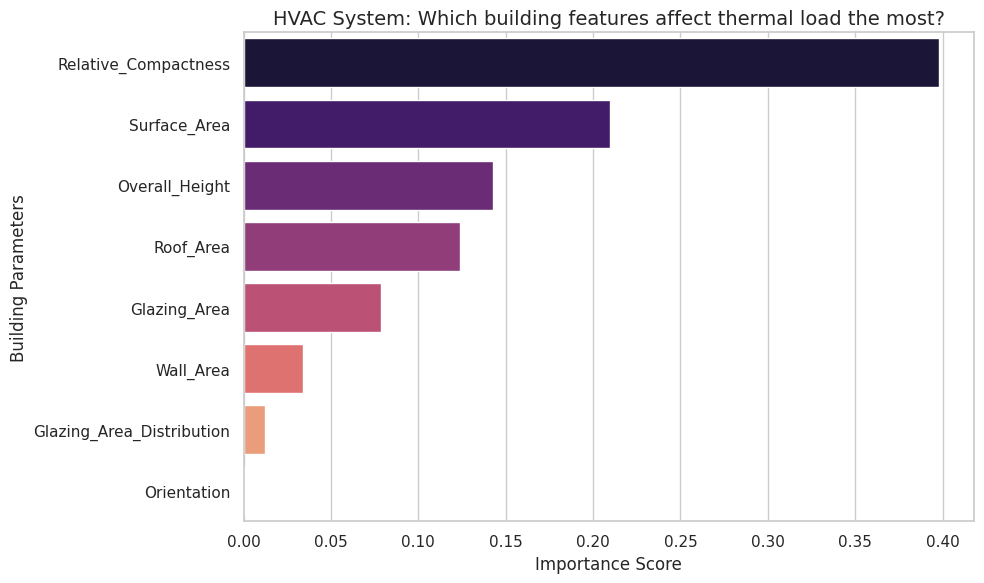


📁 Model successfully saved as 'hvac_multi_model.pkl'
Download this file from the folder icon on the left panel for the next step!


In [ ]:

# 1. Importing Advanced Libraries
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

print("Starting Advanced Multi-Output Model Training...\n")

# 2. Preparing Data for BOTH Heating and Cooling Load
X = df.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y_multi = df[['Heating_Load', 'Cooling_Load']] # Targeting both outputs

# 3. Splitting the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_multi, test_size=0.2, random_state=42)

# 4. Creating an Advanced Multi-Output Random Forest Model
# Increasing n_estimators to 200 for better accuracy
base_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
advanced_model = MultiOutputRegressor(base_model)

# 5. Training the Model
advanced_model.fit(X_train, y_train)

# 6. Testing the Model
predictions = advanced_model.predict(X_test)

# 7. Evaluating the Results separately for Heating and Cooling
heat_r2 = r2_score(y_test['Heating_Load'], predictions[:, 0])
cool_r2 = r2_score(y_test['Cooling_Load'], predictions[:, 1])

print("✅ Model Training Completed Successfully!")
print("-" * 40)
print(f"🌡️ Heating Load Prediction Accuracy: {heat_r2 * 100:.2f}%")
print(f"❄️ Cooling Load Prediction Accuracy: {cool_r2 * 100:.2f}%")
print("-" * 40)

# ==========================================
# 8. FEATURE IMPORTANCE: Mechanical Engineering Insight
# ==========================================
# Extracting feature importance from the underlying Random Forest model
feature_importances = advanced_model.estimators_[0].feature_importances_

# Creating a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plotting the Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('HVAC System: Which building features affect thermal load the most?', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Building Parameters')
plt.tight_layout()
plt.show()

# ==========================================
# 9. EXPORTING THE MODEL FOR WEB DEPLOYMENT
# ==========================================
# Saving the trained model as a .pkl file
joblib.dump(advanced_model, 'hvac_multi_model.pkl')
print("\n📁 Model successfully saved as 'hvac_multi_model.pkl'")
print("Download this file from the folder icon on the left panel for the next step!")